## This notebook demonstrates how to set up your own region for EF5

In [4]:
import numpy as np
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rioxarray as rxr
import shapely
from shapely.geometry import mapping

## Set up Project Directory
Create empty folders like below

Example:
```Text
.
├── data
├── integration
├── observations
├── preciprate
├── preciprate_temp
├── preciprate_tif
├── results
└── states

## Download Shapefile
I downloaded mine from [USGS StreamStats](https://streamstats.usgs.gov/)

Test Gage: [Kewaunee River Near Kewaunee, WI - USGS-04085200](https://waterdata.usgs.gov/monitoring-location/04085200/)


/home/apreucil/Code/.venv-grib2/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


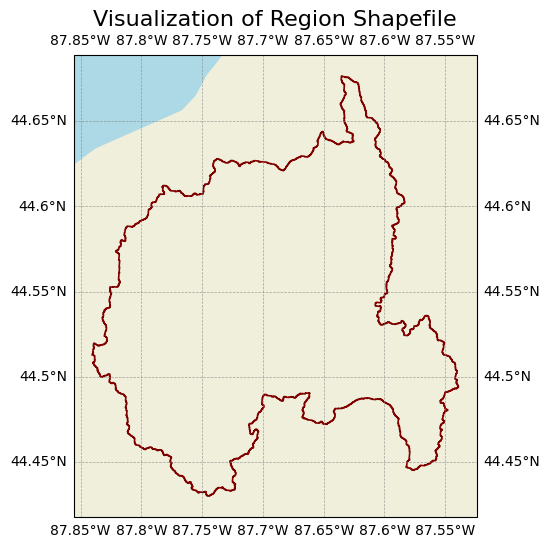

In [18]:
## Load the shapefile for the study region
ef5_shape = gpd.read_file('/home/apreucil/Kewaunee/data/layers/globalwatershed.shp')

##Visualization
# Create the figure and axis with geographic projection
fig, ax = plt.subplots(figsize=(9, 6), subplot_kw={"projection": ccrs.PlateCarree()})
# Add country borders, land, ocean and rivers
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.LAKES, color='lightblue')
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.RIVERS, color='lightblue')
ax.add_feature(cfeature.BORDERS, linestyle='--', edgecolor='black')
# Add the study region shapefile
ef5_shape.plot(ax=ax, edgecolor='maroon', facecolor='none', linewidth=1.2)
# Style the map
ax.set_title("Visualization of Region Shapefile", fontsize=16)
ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')

plt.show()

In [ ]:
# Define a function to clip the raster using the shapefile boundary. 
# This function will be used to clip rasters of parameter sets 
# predetermined by the research group at Iowa.

def clip_raster(pathraster, shapefile):
    raster = rxr.open_rasterio(pathraster, masked=True).squeeze()
    raster_clipped = raster.rio.clip(shapefile.geometry.apply(mapping))
    raster_clipped = raster_clipped.astype('float32')  # Set data type to float32
    array = raster_clipped.values
    array = np.where(np.isnan(array), -9999, array)  # conver nan values to -9999
    raster_output = raster_clipped.copy()
    raster_output.values = array
    raster_output.rio.write_nodata(int(-9999), inplace=True)  # Set NoData value to -9999
    raster_output.rio.write_crs("EPSG:4326", inplace=True)  # Set CRS to EPSG:4326

    return raster_output

## Clip Rasters
Full datasets for the US can be downloaded from the [EF5-US-Parameters](https://github.com/HyDROSLab/EF5-US-Parameters) Repository

Clone into a new folder

git clone https://github.com/HyDROSLab/EF5-US-Parameters.git

This should have the structure:
```test
.
├── PET
│   ├── PET_01_usa.tif
│   ├── PET_02_usa.tif
│   ├── PET_03_usa.tif
│   ├── PET_04_usa.tif
│   ├── PET_05_usa.tif
│   ├── PET_06_usa.tif
│   ├── PET_07_usa.tif
│   ├── PET_08_usa.tif
│   ├── PET_09_usa.tif
│   ├── PET_10_usa.tif
│   ├── PET_11_usa.tif
│   └── PET_12_usa.tif
├── README.md
├── basic
│   ├── dem_usa.tif
│   ├── facc_usa.tif
│   └── fdir_usa.tif
├── crest.txt
├── crest_params
│   ├── b_usa.tif
│   ├── im_usa.tif
│   ├── im_usa_old.tif
│   ├── ksat_usa.tif
│   └── wm_usa.tif
├── kw_params
│   ├── alpha0_usa.tif
│   ├── alpha_usa.tif
│   ├── beta_usa.tif
│   ├── ksat_usa.tif
│   └── leaki_usa.tif
├── sac.txt
└── sac_params
    ├── lzfpm_usa.tif
    ├── lzfsm_usa.tif
    ├── lzpk_usa.tif
    ├── lzsk_usa.tif
    ├── lztwm_usa.tif
    ├── pfree_usa.tif
    ├── rexp_usa.tif
    ├── uzfwm_usa.tif
    ├── uzk_usa.tif
    ├── uztwm_usa.tif
    └── zperc_usa.tif

In [ ]:
# Set path to your cloned repository and the rasters you want to clip.
dem_path = "/home/apreucil/DATA/EF5-US-Parameters/basic/dem_usa.tif"
facc_path = "/home/apreucil/DATA/EF5-US-Parameters/basic/facc_usa.tif"
fdir_path = "/home/apreucil/DATA/EF5-US-Parameters/basic/fdir_usa.tif"

# Apply the clipping function
dem_clipped = clip_raster(dem_path, ef5_shape)
facc_clipped = clip_raster(facc_path, ef5_shape)
fdir_clipped = clip_raster(fdir_path, ef5_shape)

# Save the clipped rasters to your project directory.
dem_clipped.rio.to_raster("/home/apreucil/Kewaunee/data/basic/dem_clipped.tif")
facc_clipped.rio.to_raster("/home/apreucil/Kewaunee/data/basic/facc_clipped.tif")
fdir_clipped.rio.to_raster("/home/apreucil/Kewaunee/data/basic/fdir_clipped.tif")

In [ ]:
# Optional: Investigate NoData values

# what is the nodata value in the original rasters?
with rasterio.open(dem_path) as src:
    dem_nodata = src.nodata
with rasterio.open(facc_path) as src:
    facc_nodata = src.nodata
with rasterio.open(fdir_path) as src:
    fdir_nodata = src.nodata

print(f"DEM NoData value: {dem_nodata}")
print(f"FACC NoData value: {facc_nodata}")
print(f"FDIR NoData value: {fdir_nodata}")

DEM NoData value: -9999.0
FACC NoData value: -9999.0
FDIR NoData value: -9999.0


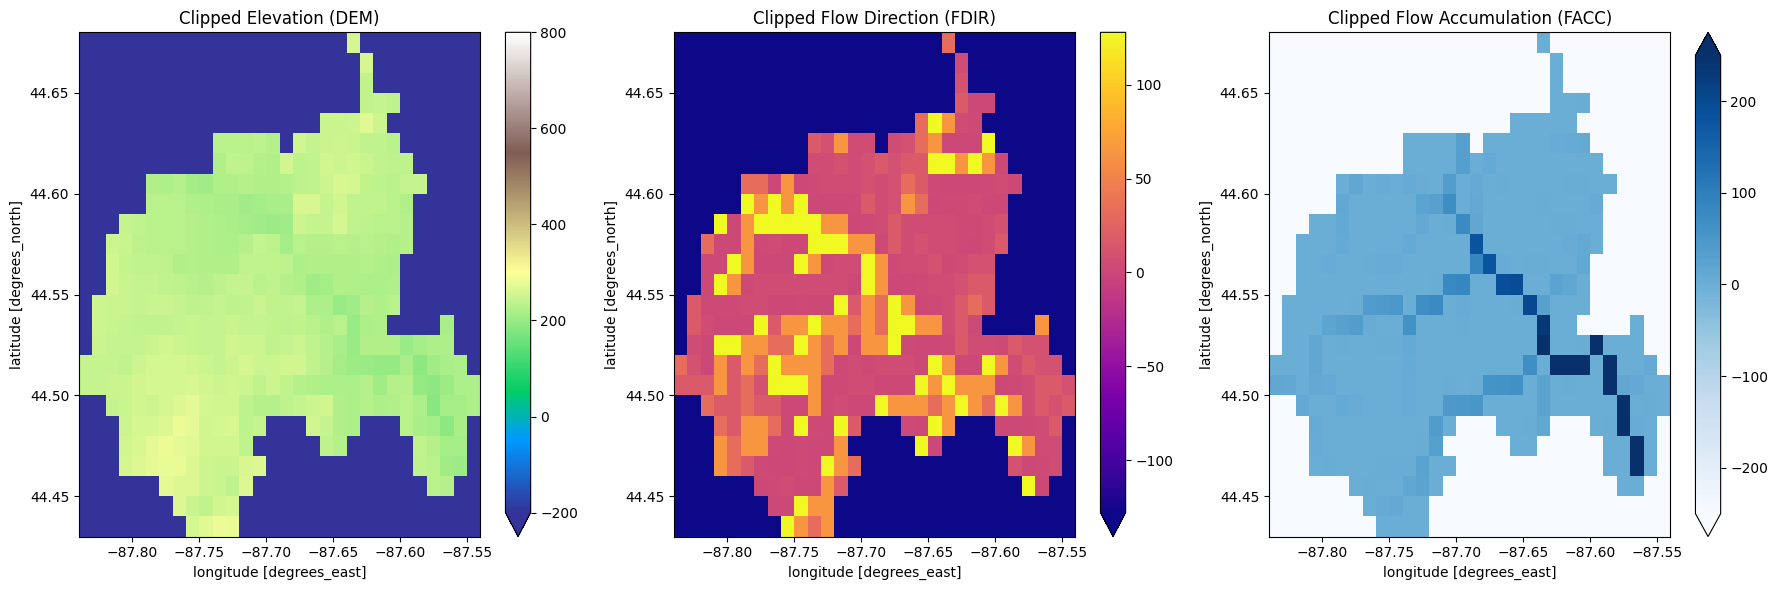

In [ ]:
# Visualize the clipped rasters to confirm they look correct
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

dem_clipped.plot(ax=axes[0], vmin=-200, vmax=800, cmap='terrain')
axes[0].set_title('Clipped Elevation (DEM)')

fdir_clipped.plot(ax=axes[1], vmax=128, cmap='plasma')
axes[1].set_title('Clipped Flow Direction (FDIR)')

facc_clipped.plot(ax=axes[2], cmap='Blues', vmax=250)
axes[2].set_title('Clipped Flow Accumulation (FACC)')

plt.tight_layout()
plt.show()

# Next, download MRMS data using script
```bash 
./download_mrms_preciprate.sh -h

Usage: download_mrms_preciprate.sh [OPTIONS]

Download MRMS PrecipRate .gz files from mtarchive and decompress them.

Options:
  -s, --start-date YYYY-MM-DD   Start date (inclusive). Default: 2022-07-27
  -e, --end-date YYYY-MM-DD     End date (inclusive). Default: 2022-07-30
  -d, --dest-dir PATH           Destination directory. Default: ~/MRMS_preciprate
  -n, --dry-run                 Show what would be downloaded/skipped without changes
  -h, --help                    Show this help message

```
Then run the following cell to conver the grib files to tif. Set the path to your files, and output folder where the tif files will be stored. 

In [ ]:
# Convert grib2 to tif. This cell uses multiple processes to convert only missing files.
# It also replaces missing and no coverage data with -9999 using gdal_calc.py.

# Prerequiste: Install gdal-bin:
# sudo apt-get install gdal-bin

import subprocess
import os
from concurrent.futures import ProcessPoolExecutor

# Set your directories
path_to_files = r'/home/apreucil/Kewaunee/preciprate'
output_path = r'/home/apreucil/Kewaunee/preciprate_tif'
temp_output_path = r'/home/apreucil/Kewaunee/preciprate_temp'

# Do not alter below.
files = [f for f in os.listdir(path_to_files) if f.endswith('.grib2')]

file = files[0]

def convert_grib_to_tif(file):
    output_name = os.path.basename(file)[:-6] + '.tif'  # Remove .grib2 extension

    # create the output directories if they don't exist
    os.makedirs(output_path, exist_ok=True)
    os.makedirs(temp_output_path, exist_ok=True)

    final_output = os.path.join(output_path, output_name)
    if os.path.exists(final_output):
        print(f'Skipping existing file: {output_name}')
        return

    # Install gdal-bin:
    # sudo apt-get install gdal-bin

    missing = -1
    no_coverage = -3
    try:
        # Step 1: Convert .grib2 to .tif
        command_translate = f"gdal_translate -of GTiff -a_nodata -9999 -ot Float32 -a_srs EPSG:4326 {os.path.join(path_to_files, file)} {os.path.join(temp_output_path, output_name)}"
        subprocess.run(command_translate, shell=True, check=True)

        # Step 2: Replace missing and no coverage data with -9999 using gdal_calc.py
        command_calc = (
            f"gdal_calc.py --overwrite --quiet "
            f"-A {os.path.join(temp_output_path, output_name)} --outfile={final_output} "
            f"--calc='numpy.where((A=={missing}) | (A=={no_coverage}) | (A==-9999), -9999, A)' "
            f"--NoDataValue=-9999 --type=Float32"
        )
        subprocess.run(command_calc, shell=True, check=True)

        # Remove the temporary file
        os.remove(os.path.join(temp_output_path, output_name))

        print(f'File converted and corrected: {output_name}')

    except Exception as e:
        print(f"Error processing file {file}: {str(e)}")

# Implement a parallel processing to convert only missing files

os.makedirs(output_path, exist_ok=True)

files_to_convert = [
    file for file in files
    if not os.path.exists(os.path.join(output_path, os.path.basename(file)[:-6] + '.tif'))
]

print(f"Using {os.cpu_count()} processes for conversion.")
print(f"Found {len(files)} .grib2 files total.")
print(f"Skipping {len(files) - len(files_to_convert)} already converted files.")
print(f"Converting {len(files_to_convert)} files...")

if files_to_convert:
    with ProcessPoolExecutor() as executor:
        executor.map(convert_grib_to_tif, files_to_convert)
    print("Missing files converted successfully.")
else:
    print("No new files to convert.")


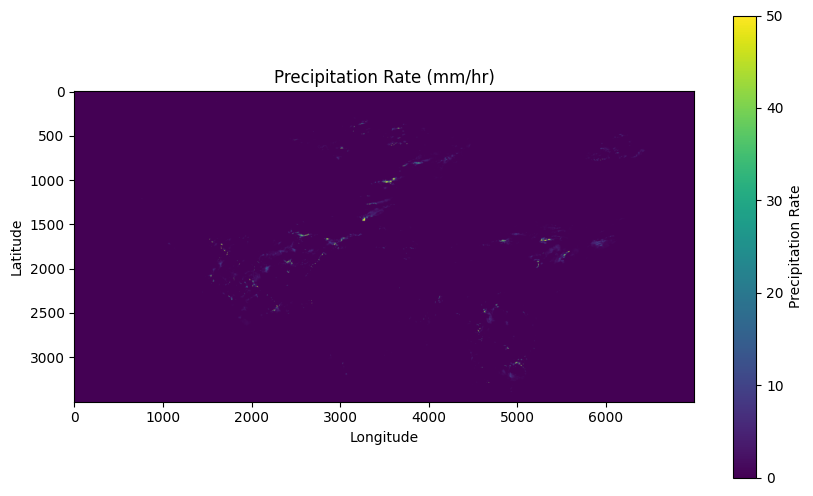

In [ ]:
# Visualize one of the tif files we just converted
output_path = r'/home/apreucil/Kewaunee/preciprate_tif'
output_name = os.path.basename(files[0])[:-6] + '.tif' # defaulting to the first file

# Visualize the tif file we just converted
tif_path = os.path.join(output_path, output_name)
with rasterio.open(tif_path) as src:
    data = src.read(1)
    plt.figure(figsize=(10, 6))
    plt.imshow(data, cmap='viridis', vmin=0, vmax=50)
    plt.colorbar(label='Precipitation Rate')
    plt.title('Precipitation Rate (mm/hr)')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

## Parameters
The CREST, SAC, and KW parameters have already been created for CONUS, you can get them via the dockerized EF5 installation.
[Add Link!]

We can just clip the parameter files to the region for better data io.

In [1]:
import os
import rioxarray as rxr
from rasterio.warp import transform_bounds

def clip_tif_folder_to_dem_extent(source_folder, target_folder, dem_clipped_path):
    os.makedirs(target_folder, exist_ok=True)

    dem = rxr.open_rasterio(dem_clipped_path, masked=True)
    dem_bounds = dem.rio.bounds()
    dem_crs = dem.rio.crs

    tif_files = sorted([f for f in os.listdir(source_folder) if f.lower().endswith('.tif')])
    if not tif_files:
        print(f'No .tif files found in: {source_folder}')
        return

    for tif_name in tif_files:
        in_path = os.path.join(source_folder, tif_name)
        out_path = os.path.join(target_folder, tif_name)

        raster = rxr.open_rasterio(in_path, masked=True)
        if raster.rio.crs is None:
            print(f'Skipping {tif_name}: missing CRS')
            continue

        clip_bounds = dem_bounds
        if raster.rio.crs != dem_crs:
            clip_bounds = transform_bounds(dem_crs, raster.rio.crs, *dem_bounds)

        clipped = raster.rio.clip_box(
            minx=clip_bounds[0],
            miny=clip_bounds[1],
            maxx=clip_bounds[2],
            maxy=clip_bounds[3]
        )
        clipped.rio.to_raster(out_path)
        print(f'Wrote: {out_path}')

In [2]:
clip_tif_folder_to_dem_extent('/home/apreucil/DATA/EF5-US-Parameters/crest_params',
                              '/home/apreucil/Kewaunee/data/crest_params',
                              '/home/apreucil/Kewaunee/data/basic/dem_clipped.tif')

Wrote: /home/apreucil/Kewaunee/data/crest_params/b_usa.tif
Wrote: /home/apreucil/Kewaunee/data/crest_params/im_usa.tif
Wrote: /home/apreucil/Kewaunee/data/crest_params/im_usa_old.tif
Wrote: /home/apreucil/Kewaunee/data/crest_params/ksat_usa.tif
Wrote: /home/apreucil/Kewaunee/data/crest_params/wm_usa.tif


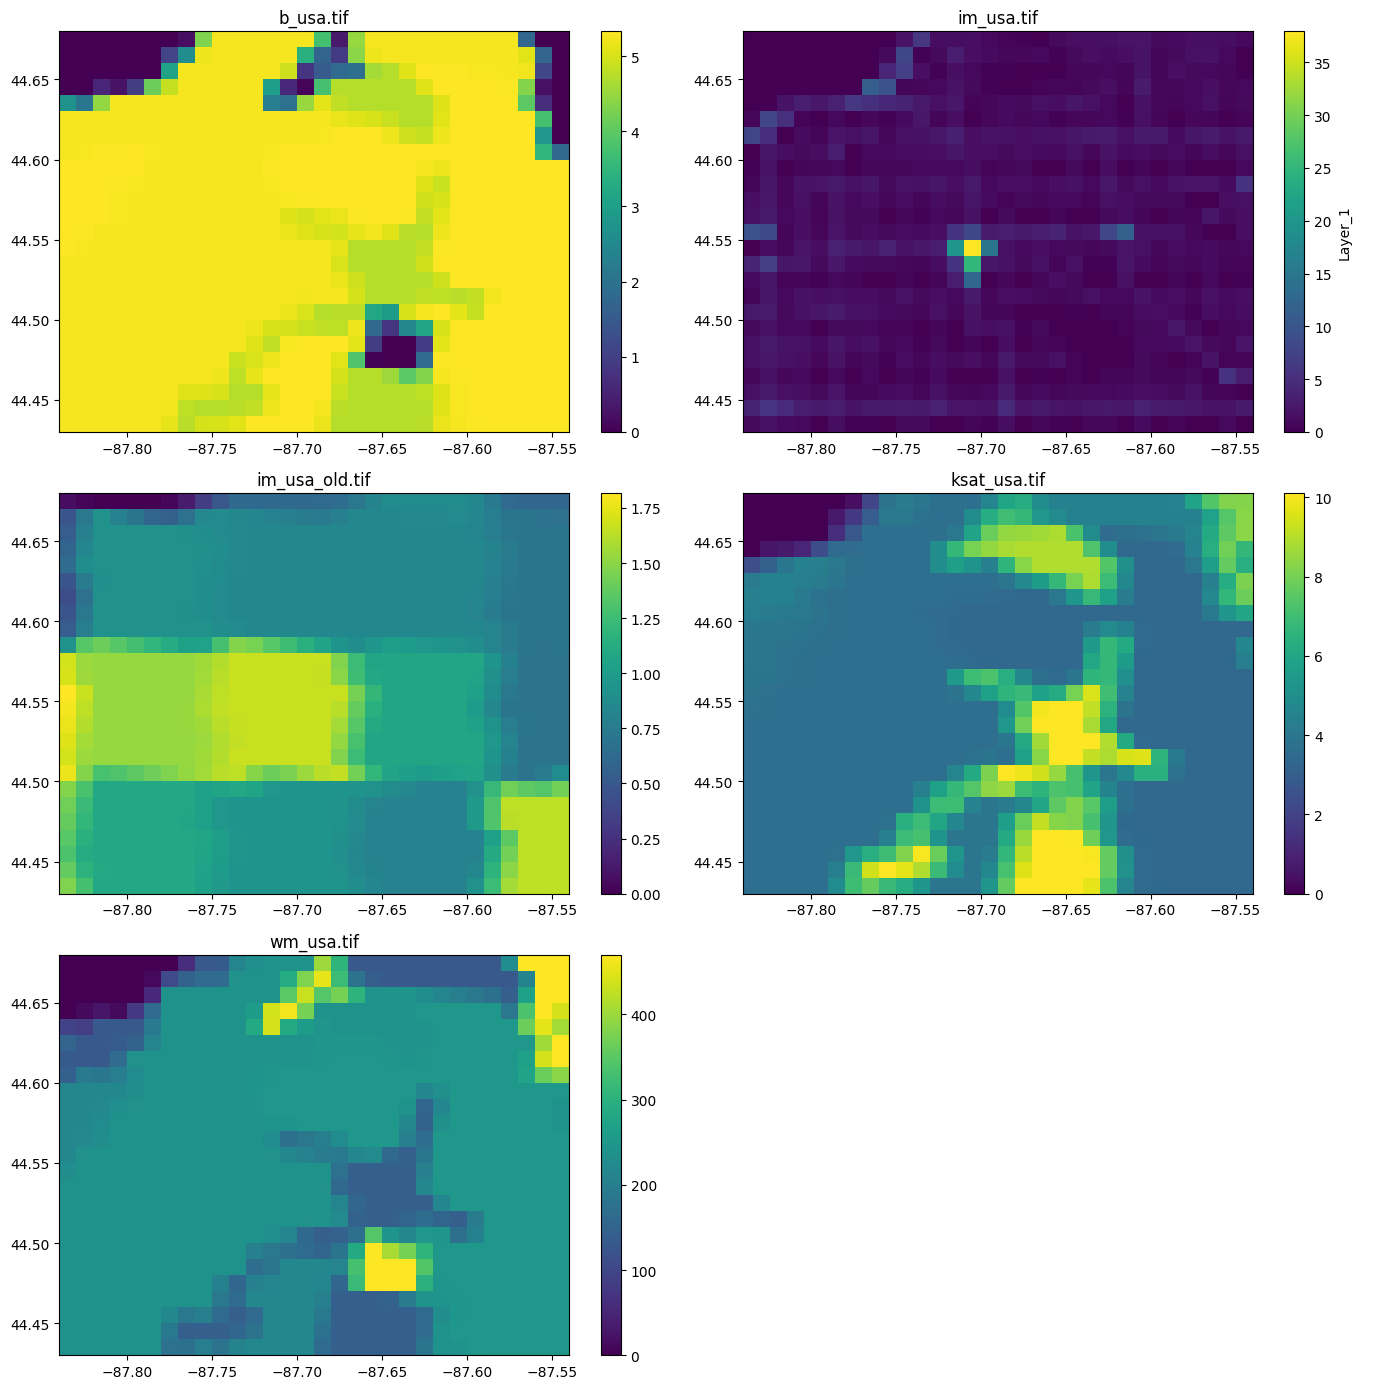

In [5]:
import os

clipped_folder = '/home/apreucil/Kewaunee/data/crest_params'
tif_files = sorted([f for f in os.listdir(clipped_folder) if f.lower().endswith('.tif')])

if not tif_files:
    print(f'No clipped .tif files found in {clipped_folder}')
else:
    fig, axes = plt.subplots(3, 2, figsize=(14, 14))
    axes = axes.flatten()

    for i, tif_name in enumerate(tif_files[:6]):
        tif_path = os.path.join(clipped_folder, tif_name)
        raster = rxr.open_rasterio(tif_path, masked=True).squeeze()
        raster.plot(ax=axes[i], cmap='viridis')
        axes[i].set_title(tif_name)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')

    for j in range(min(len(tif_files), 6), 6):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    if len(tif_files) > 6:
        print(f'Displaying first 6 of {len(tif_files)} TIFF files.')

In [6]:
# Clip /home/apreucil/DATA/EF5-US-Parameters/sac_params tif files using our function
clip_tif_folder_to_dem_extent('/home/apreucil/DATA/EF5-US-Parameters/sac_params',
                              '/home/apreucil/Kewaunee/data/sac_params',
                              '/home/apreucil/Kewaunee/data/basic/dem_clipped.tif')

Wrote: /home/apreucil/Kewaunee/data/sac_params/lzfpm_usa.tif
Wrote: /home/apreucil/Kewaunee/data/sac_params/lzfsm_usa.tif
Wrote: /home/apreucil/Kewaunee/data/sac_params/lzpk_usa.tif
Wrote: /home/apreucil/Kewaunee/data/sac_params/lzsk_usa.tif
Wrote: /home/apreucil/Kewaunee/data/sac_params/lztwm_usa.tif
Wrote: /home/apreucil/Kewaunee/data/sac_params/pfree_usa.tif
Wrote: /home/apreucil/Kewaunee/data/sac_params/rexp_usa.tif
Wrote: /home/apreucil/Kewaunee/data/sac_params/uzfwm_usa.tif
Wrote: /home/apreucil/Kewaunee/data/sac_params/uzk_usa.tif
Wrote: /home/apreucil/Kewaunee/data/sac_params/uztwm_usa.tif
Wrote: /home/apreucil/Kewaunee/data/sac_params/zperc_usa.tif


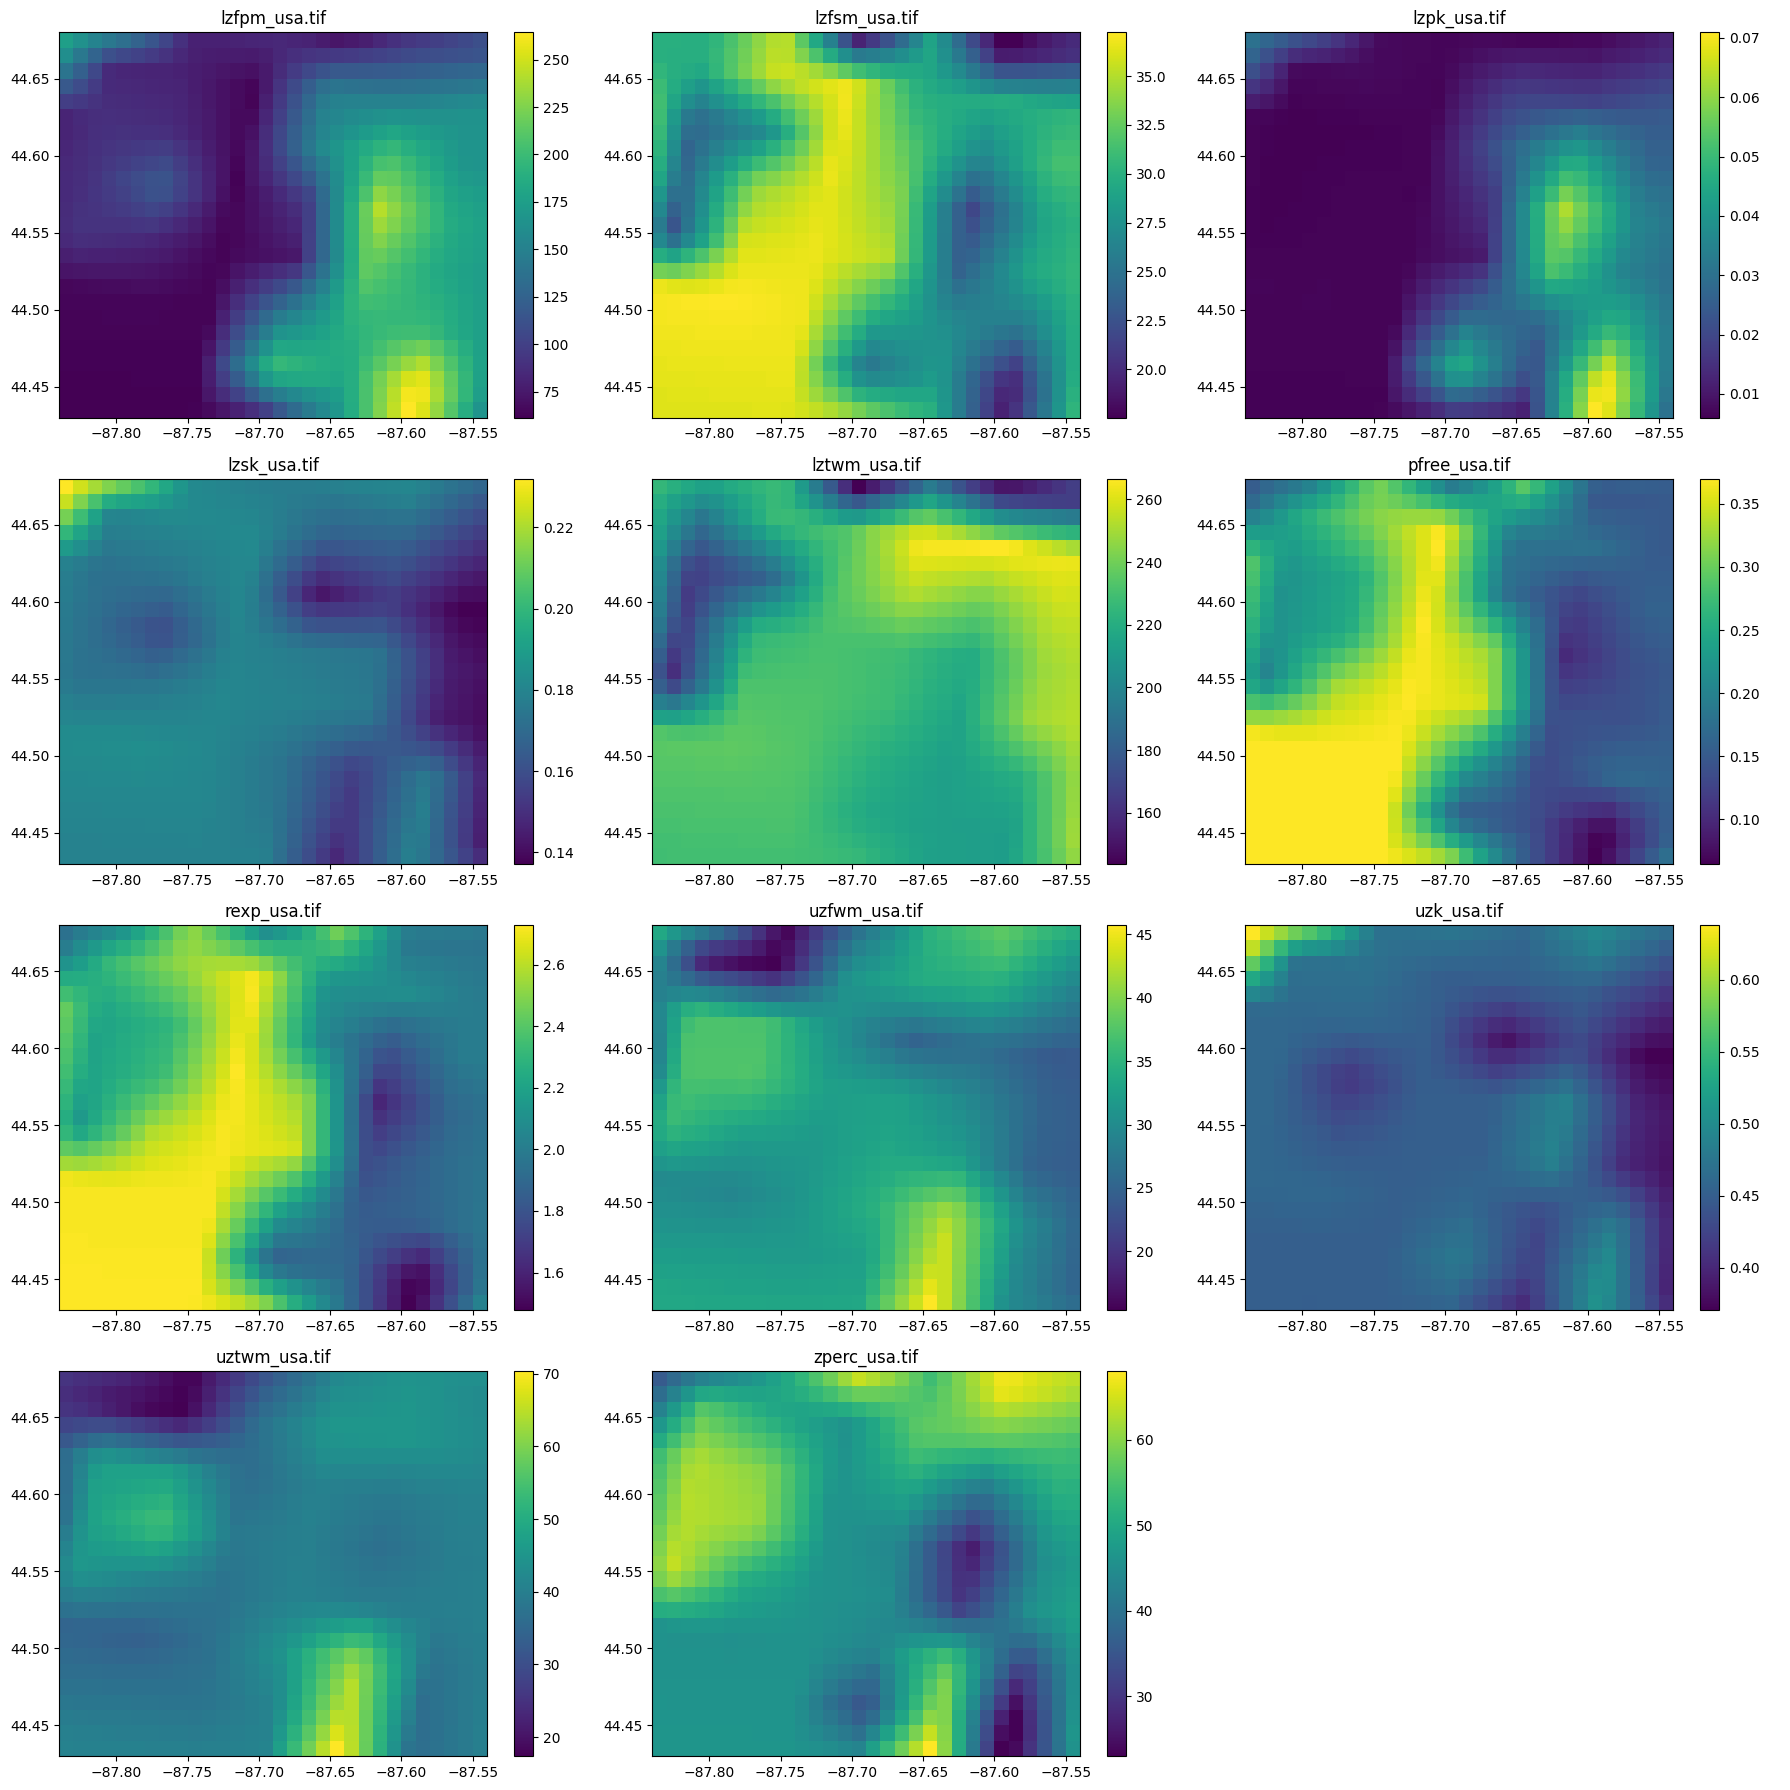

In [7]:
sac_clipped_folder = '/home/apreucil/Kewaunee/data/sac_params'
sac_tif_files = sorted([f for f in os.listdir(sac_clipped_folder) if f.lower().endswith('.tif')])

if not sac_tif_files:
    print(f'No clipped .tif files found in {sac_clipped_folder}')
else:
    fig, axes = plt.subplots(4, 3, figsize=(18, 18))
    axes = axes.flatten()

    for i, tif_name in enumerate(sac_tif_files[:12]):
        tif_path = os.path.join(sac_clipped_folder, tif_name)
        raster = rxr.open_rasterio(tif_path, masked=True).squeeze()
        raster.plot(ax=axes[i], cmap='viridis')
        axes[i].set_title(tif_name)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')

    for j in range(min(len(sac_tif_files), 12), 12):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    if len(sac_tif_files) > 12:
        print(f'Displaying first 12 of {len(sac_tif_files)} TIFF files.')

In [8]:
# Clip kw params using our function
clip_tif_folder_to_dem_extent('/home/apreucil/DATA/EF5-US-Parameters/kw_params',
                              '/home/apreucil/Kewaunee/data/kw_params',
                              '/home/apreucil/Kewaunee/data/basic/dem_clipped.tif')

Wrote: /home/apreucil/Kewaunee/data/kw_params/alpha0_usa.tif
Wrote: /home/apreucil/Kewaunee/data/kw_params/alpha_usa.tif
Wrote: /home/apreucil/Kewaunee/data/kw_params/beta_usa.tif
Wrote: /home/apreucil/Kewaunee/data/kw_params/ksat_usa.tif
Wrote: /home/apreucil/Kewaunee/data/kw_params/leaki_usa.tif


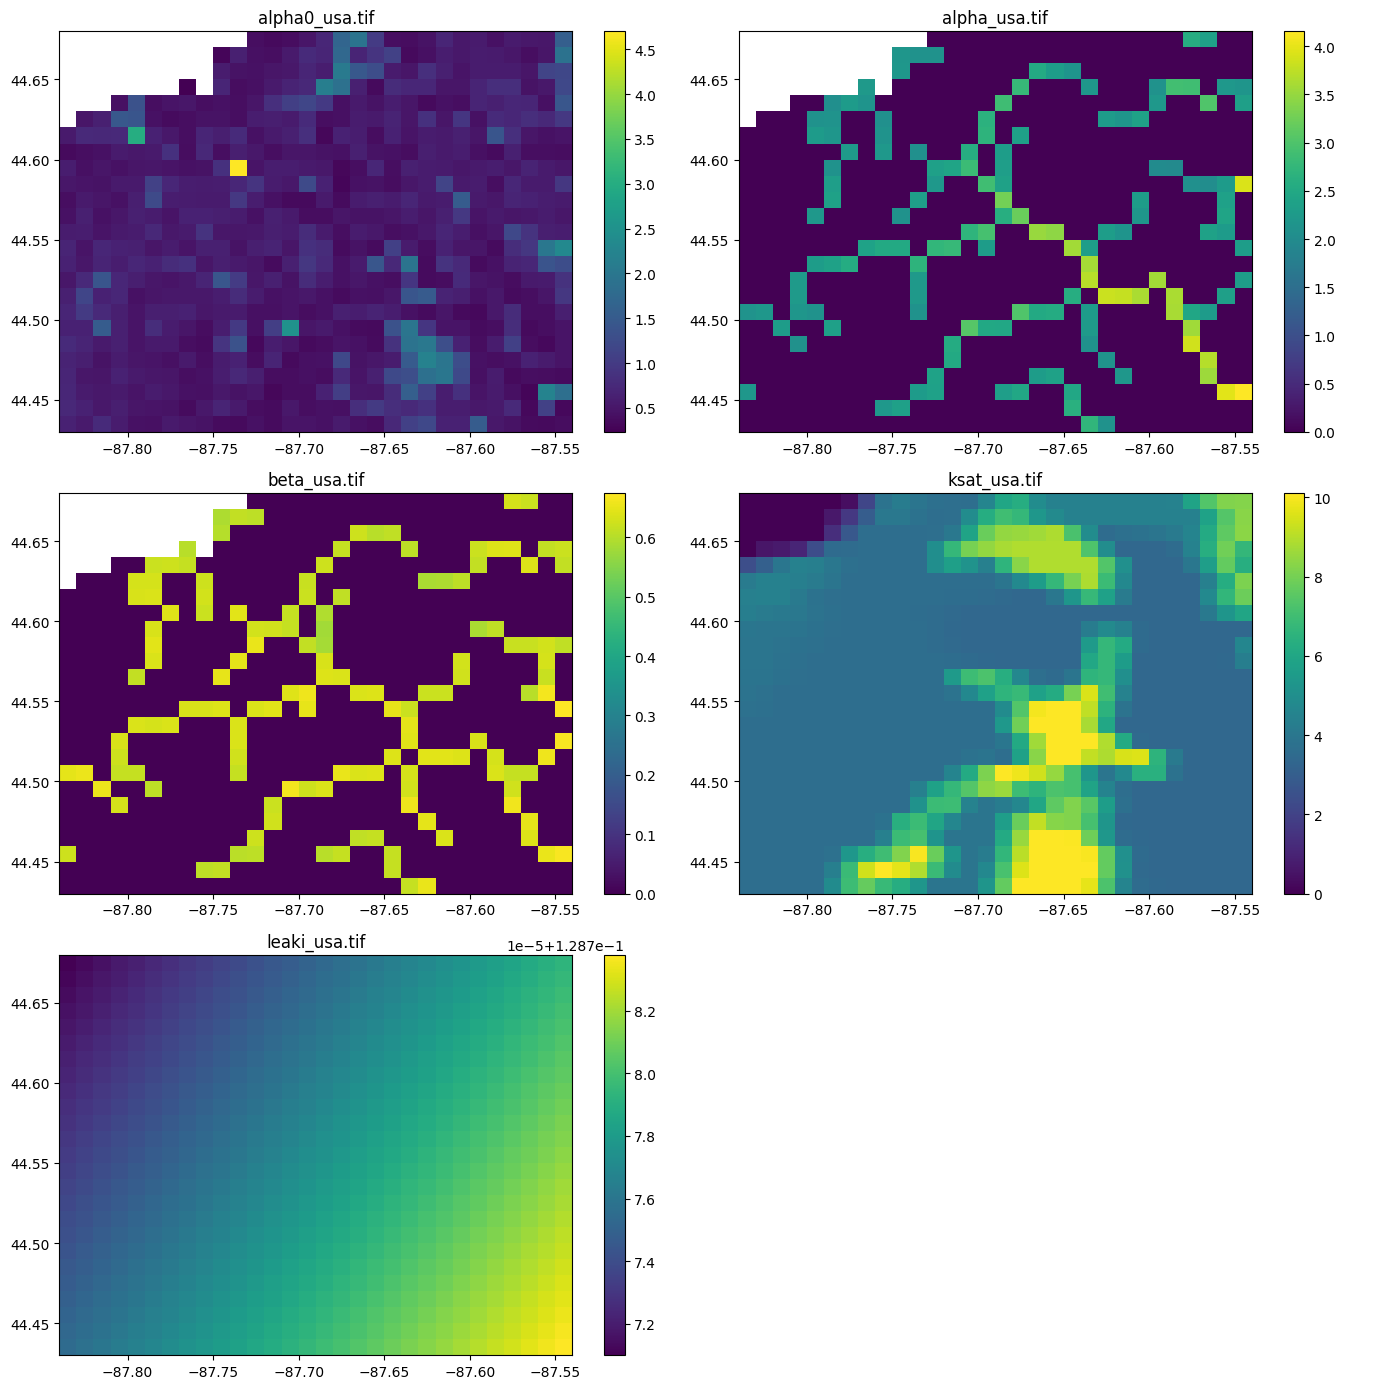

In [9]:
kw_clipped_folder = '/home/apreucil/Kewaunee/data/kw_params'
kw_tif_files = sorted([f for f in os.listdir(kw_clipped_folder) if f.lower().endswith('.tif')])

if not kw_tif_files:
    print(f'No clipped .tif files found in {kw_clipped_folder}')
else:
    fig, axes = plt.subplots(3, 2, figsize=(14, 14))
    axes = axes.flatten()

    for i, tif_name in enumerate(kw_tif_files[:6]):
        tif_path = os.path.join(kw_clipped_folder, tif_name)
        raster = rxr.open_rasterio(tif_path, masked=True).squeeze()
        raster.plot(ax=axes[i], cmap='viridis')
        axes[i].set_title(tif_name)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')

    for j in range(min(len(kw_tif_files), 6), 6):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    if len(kw_tif_files) > 6:
        print(f'Displaying first 6 of {len(kw_tif_files)} TIFF files.')

## Clip to Gauge

Set up a control file to clip to gage. Output will end up in the intgration folder. You can visualize the created maskgrid.tif below.

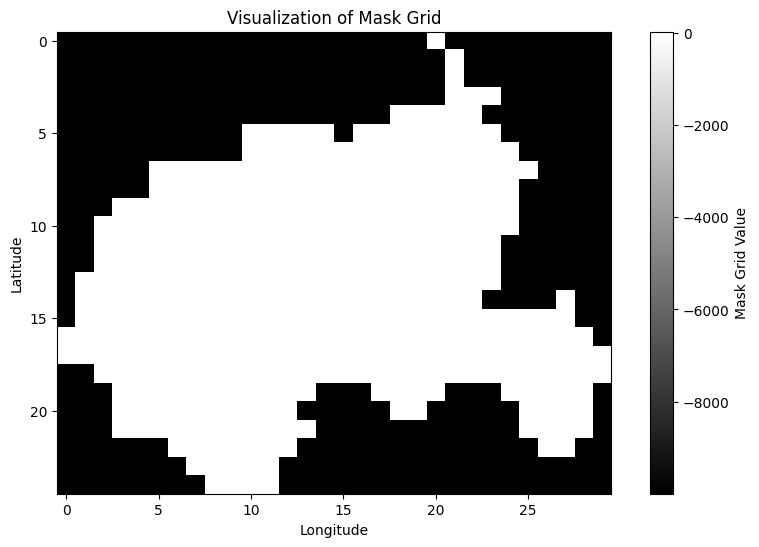

In [26]:
# Visualize the tif: /home/apreucil/Kewaunee/integration/maskgrid.tif
maskgrid_path = '/home/apreucil/Kewaunee/integration/maskgrid.tif'
with rasterio.open(maskgrid_path) as src:
    maskgrid_data = src.read(1)
    plt.figure(figsize=(10, 6))
    plt.imshow(maskgrid_data, cmap='gray')
    plt.colorbar(label='Mask Grid Value')
    plt.title('Visualization of Mask Grid')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

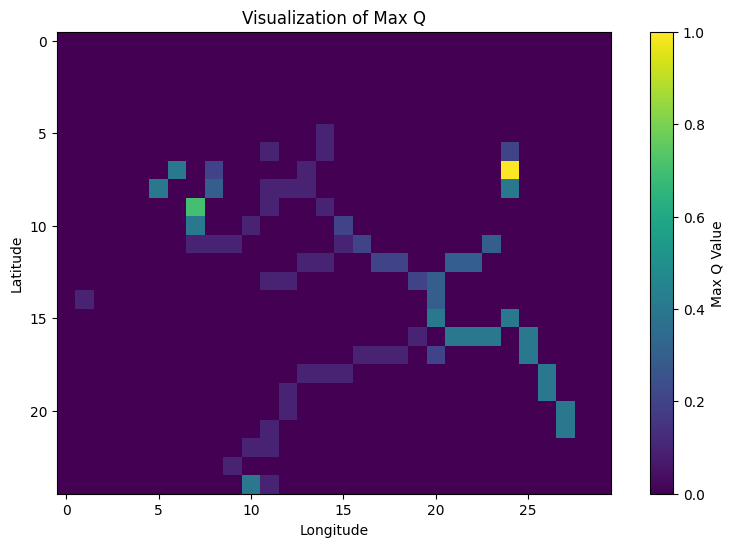

In [28]:
# Next visualize this tif /home/apreucil/Kewaunee/results/maxq.20220727.120000.tif
maxq_path = '/home/apreucil/Kewaunee/results/maxq.20220727.120000.tif'
with rasterio.open(maxq_path) as src:
    maxq_data = src.read(1)
    plt.figure(figsize=(10, 6))
    plt.imshow(maxq_data, cmap='viridis', vmin=0, vmax=1)
    plt.colorbar(label='Max Q Value')
    plt.title('Visualization of Max Q')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

Index(['Time', 'Discharge(m^3 s^-1)', 'Observed(m^3 s^-1)', 'Precip(mm h^-1)',
       'PET(mm h^-1)', 'SM(%)', 'Fast Flow(mm*1000)', 'Slow Flow(mm*1000)'],
      dtype='str')


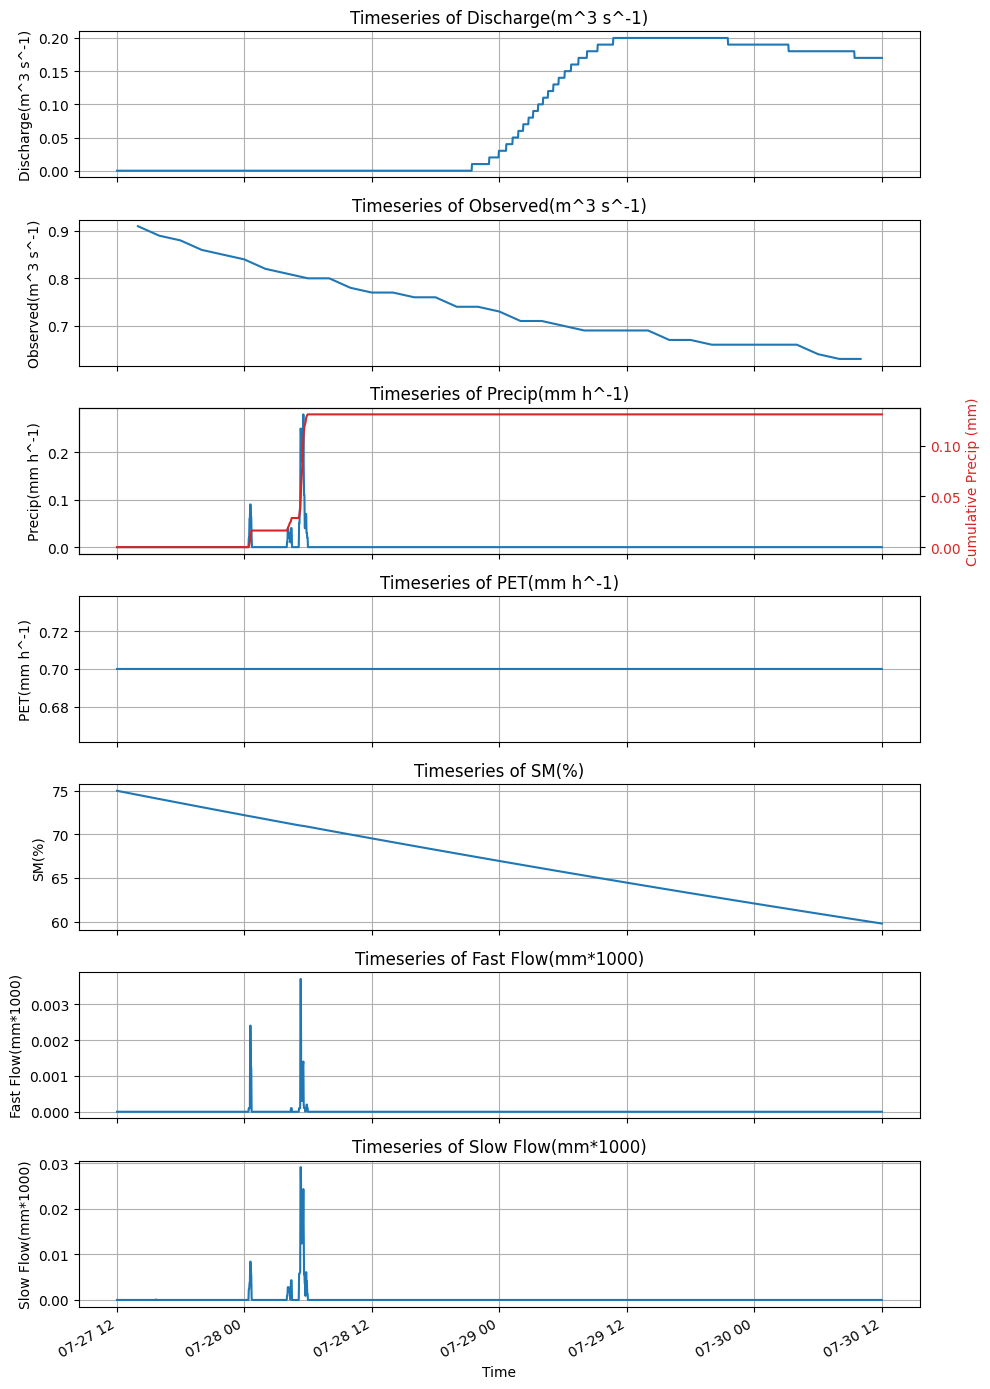

In [37]:
# Create a graph of the timeseries output /home/apreucil/Kewaunee/results/ts.0.crest.csv
import pandas as pd
ts_path = '/home/apreucil/Kewaunee/results/ts.0.crest.csv'
ts_data = pd.read_csv(ts_path)
# Read all the columns in the csv file
print(ts_data.columns)
# Plot each column as a timeseries with subplots, each plot should be long and skinny with title.
import matplotlib.pyplot as plt
import numpy as np

# Convert Time to datetime and keep valid rows
ts_data['Time'] = pd.to_datetime(ts_data['Time'], errors='coerce')
ts_data = ts_data.dropna(subset=['Time']).reset_index(drop=True)

# Coerce all data columns to numeric to handle text/mixed values (e.g., in Observed column)
for col in ts_data.columns[1:]:
    ts_data[col] = pd.to_numeric(ts_data[col], errors='coerce')

num_columns = len(ts_data.columns) - 1  # Exclude the time column
fig, axes = plt.subplots(num_columns, 1, figsize=(10, 2 * num_columns), sharex=True)
axes = np.atleast_1d(axes)

time_series = ts_data['Time']
valid_time = len(time_series) > 1

for i, column in enumerate(ts_data.columns[1:]):  # Skip the time column
    ax = axes[i]
    series = ts_data[column]

    # Plot only valid points; sparse NaNs are preserved as gaps
    valid_mask = series.notna()
    if valid_mask.any():
        ax.plot(time_series[valid_mask], series[valid_mask], color='tab:blue')
    else:
        ax.text(0.5, 0.5, 'No valid numeric data', ha='center', va='center', transform=ax.transAxes)

    ax.set_title(f'Timeseries of {column}')
    ax.set_ylabel(column)
    ax.grid()

    if column == 'Precip(mm h^-1)':
        if valid_time:
            dt_hours = time_series.diff().dt.total_seconds().div(3600.0)
            dt_hours.iloc[0] = dt_hours.iloc[1] if len(dt_hours) > 1 else 0.0
            dt_hours = dt_hours.fillna(0.0).clip(lower=0.0)
            precip_for_sum = series.fillna(0.0)
            running_sum = (precip_for_sum * dt_hours).cumsum()
            running_label = 'Cumulative Precip (mm)'
        else:
            running_sum = series.fillna(0.0).cumsum()
            running_label = 'Running Sum (index-based)'

        ax2 = ax.twinx()
        ax2.plot(time_series, running_sum, color='tab:red', linewidth=1.5)
        ax2.set_ylabel(running_label, color='tab:red')
        ax2.tick_params(axis='y', labelcolor='tab:red')

axes[-1].set_xlabel('Time')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()